In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [9]:
df_raw = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/eels/eel.csv')
wind_direction = 90*np.pi/180 + np.pi

In [10]:
scaling = 1

In [11]:
df_calibrated = df_raw*scaling

In [19]:
# estimate time stamps: each point is 2 sec apart
timestamps = np.arange(0, df_calibrated.shape[0]*1, 1)

In [20]:
df_calibrated['timestamps_sec'] = timestamps

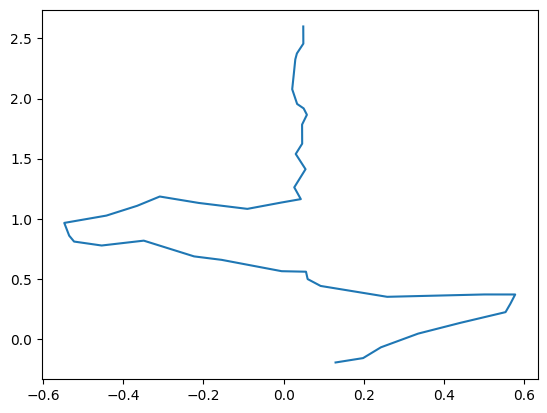

In [21]:
plt.plot(df_calibrated.x.values, df_calibrated.y.values)

In [22]:
from scipy.interpolate import UnivariateSpline

In [23]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), 0.1)

In [24]:
interp_timestamps_sec

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
       13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
       14.3, 14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15

In [39]:
spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=.01, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=.01, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

In [40]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

0.0


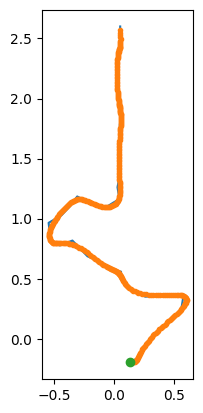

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

tix = 0
ax.plot(df_calibrated_interp.x.values[tix], df_calibrated_interp.y.values[tix], 'o')

print(df_calibrated_interp.timestamps_sec.values[tix])

ax.set_aspect('equal')

In [42]:
import pynumdiff

In [43]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [44]:
from braid_analysis import flymath

df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix]
df_calibrated_interp['obj_id_unique_event'] = 'shark_a'
df_calibrated_interp['obj_id_unique'] = 'shark_a'
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= wind_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

In [45]:
np.mean(np.sqrt(df_calibrated_interp.xvel**2 + df_calibrated_interp.yvel**2))

0.10464737500528648

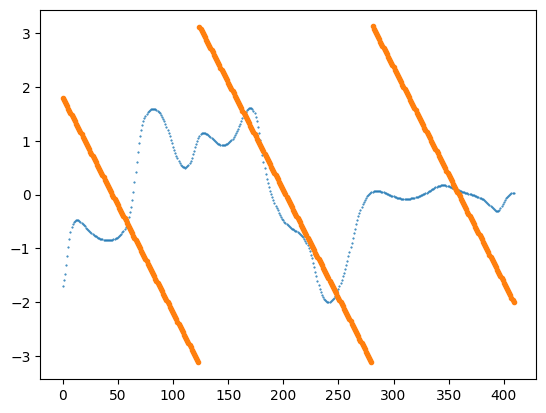

In [46]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.plot(ix, wrap_angle(line), '.')


In [47]:
from align_course_direction_analysis import unifying_algo_analysis as uaa

In [48]:
trajec = df_calibrated_interp

In [49]:
trajec.shape

(410, 11)

In [50]:
course = trajec.course_smoothish.values
abs_min_ix = tix
abs_max_ix = 350
min_ix_range = 250
max_ix_range = 300

In [51]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 30, 
                                                  n_bootstraps=2, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)

Set parameter Username
Set parameter LicenseID to value 2753061
Academic license - for non-commercial use only - expires 2026-12-11


/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [52]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [53]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,AM_1_1,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix
0,35,321,-0.040215,1.099733,1.312820,0.669202,0.109156,0.145609,0.138153,0.138153,0.632750,0.615216,-0.000236,0.399286,0.052927,0.163114,0.962885,184
1,23,294,0.089025,-5.405533,2.026933,0.535215,0.253044,0.307792,-0.111584,-0.111584,0.480467,0.531913,0.091615,0.257007,-0.016709,0.472788,1.081321,61


In [54]:
#best_unifying_algo_fit = unifying_algo_fit.iloc[0]
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

In [55]:
import figurefirst as fifi

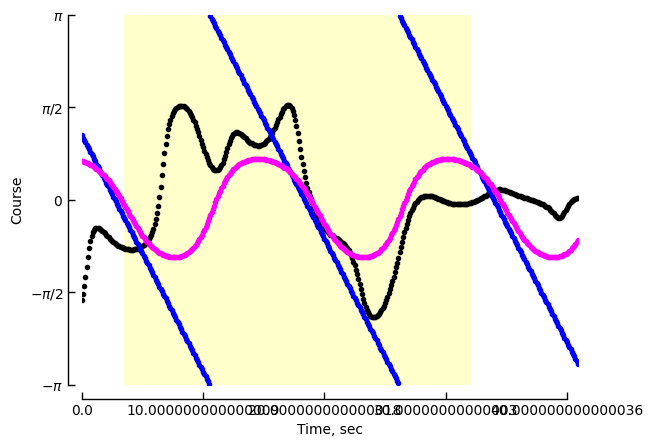

In [56]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [57]:
unifying_algo_fit['abs_slope'] = np.abs(unifying_algo_fit['slope'])
uaa.get_weighted_value(unifying_algo_fit, col='abs_slope')

0.06180150499887055

In [58]:
uaa.get_weighted_value(unifying_algo_fit, col='rho')

0.3363623601614184